In [13]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Weather Data.csv")

# Display the first 5 rows to understand the structure of the dataset
print(df.head())

# Display general information about the dataset (column names, data types, non-null values)
print(df.info())

# Display summary statistics for numerical columns
print(df.describe())


       Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0  1/1/2012 0:00    -1.8              -3.9         86                4   
1  1/1/2012 1:00    -1.8              -3.7         87                4   
2  1/1/2012 2:00    -1.8              -3.4         89                7   
3  1/1/2012 3:00    -1.5              -3.2         88                6   
4  1/1/2012 4:00    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa               Weather  
0            8.0     101.24                   Fog  
1            8.0     101.24                   Fog  
2            4.0     101.26  Freezing Drizzle,Fog  
3            4.0     101.27  Freezing Drizzle,Fog  
4            4.8     101.23                   Fog  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   obje

In [15]:
# Check for missing values in each column
print(df.isnull().sum())



Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


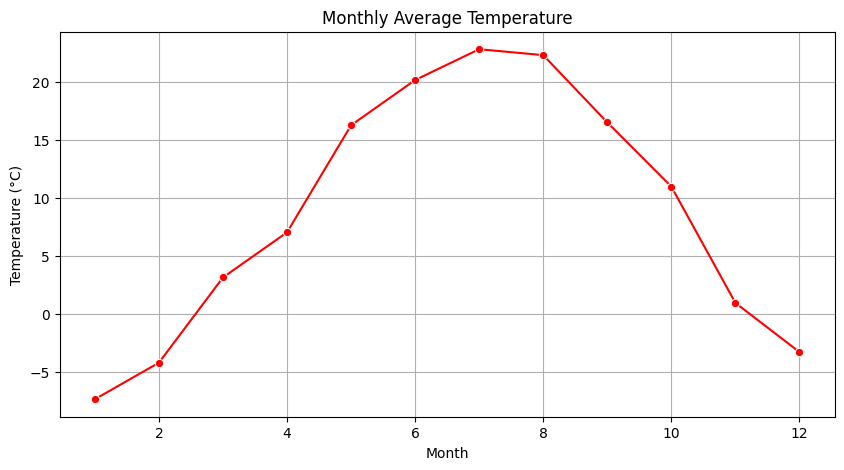

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the "Date/Time" column to datetime format
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

# Extract the month from the date
df["Month"] = df["Date/Time"].dt.month

# Calculate the average temperature for each month
monthly_avg_temp = df.groupby("Month")["Temp_C"].mean()

# Plot temperature variations throughout the year
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_avg_temp.index, y=monthly_avg_temp.values, marker="o", color="red")
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()


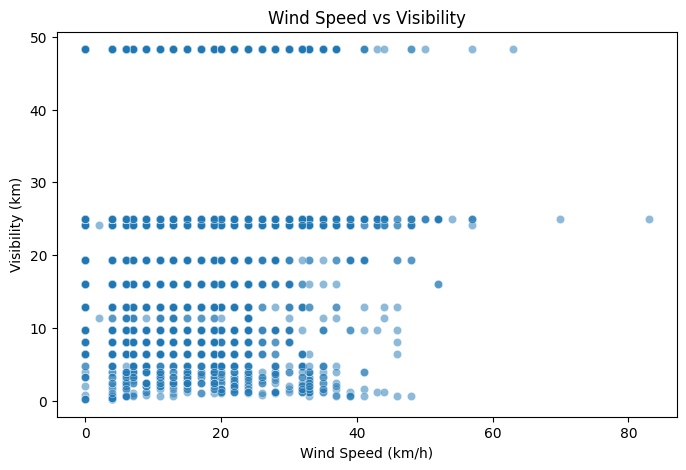

In [17]:
# Scatter plot to analyze the relationship between wind speed and visibility
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Wind Speed_km/h"], y=df["Visibility_km"], alpha=0.5)
plt.title("Wind Speed vs Visibility")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Visibility (km)")
plt.show()


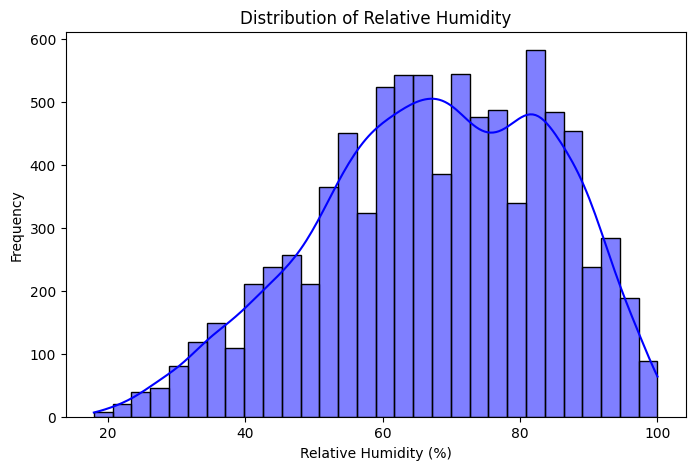

In [18]:
# Histogram to visualize the distribution of relative humidity
plt.figure(figsize=(8, 5))
sns.histplot(df["Rel Hum_%"], bins=30, kde=True, color="blue")
plt.title("Distribution of Relative Humidity")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")
plt.show()


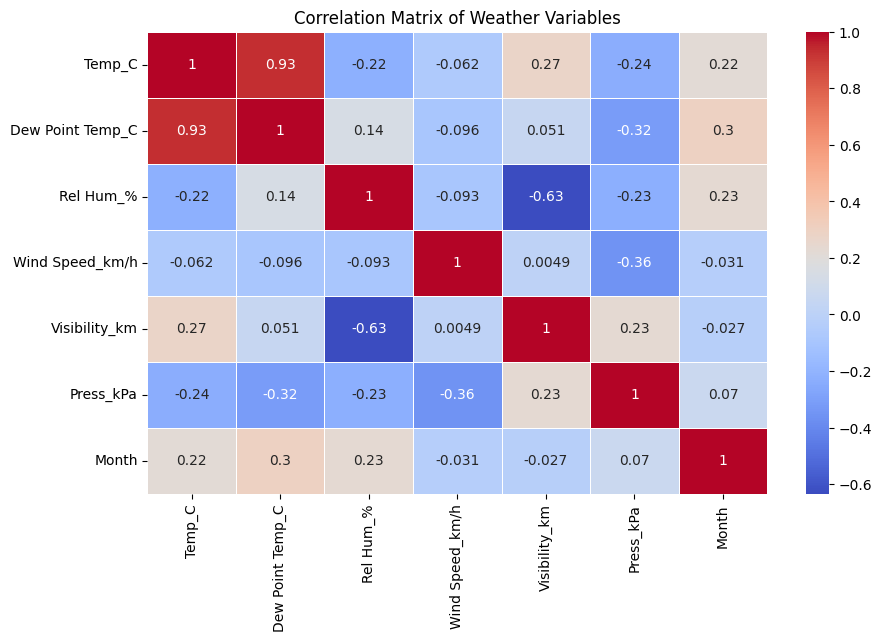

In [20]:
# Compute the correlation matrix, excluding non-numeric columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Heatmap to visualize the correlation between weather variables
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Weather Variables")
plt.show()

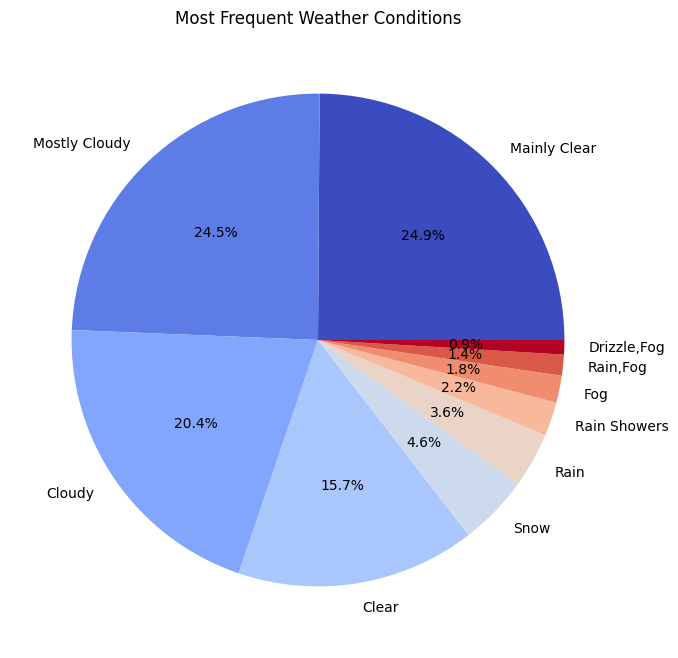

In [21]:
# Count the occurrences of different weather conditions
weather_counts = df["Weather"].value_counts()

# Pie chart to visualize the most frequent weather conditions
plt.figure(figsize=(8, 8))
weather_counts[:10].plot(kind="pie", autopct="%1.1f%%", cmap="coolwarm")
plt.title("Most Frequent Weather Conditions")
plt.ylabel("")  # Remove the default y-axis label
plt.show()


🔹 Model Accuracy: 0.12


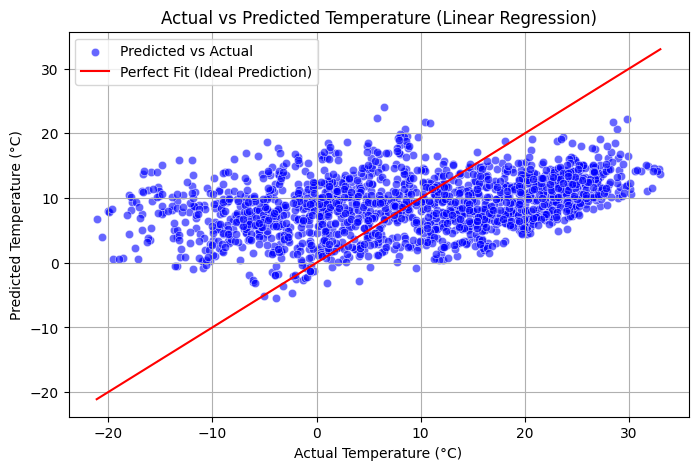

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# اختيار الميزات المستقلة والمتغير المستهدف
X = df[["Rel Hum_%", "Press_kPa"]]
y = df["Temp_C"]

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء نموذج الانحدار الخطي
model = LinearRegression()
model.fit(X_train, y_train)

# إجراء التنبؤات
y_pred = model.predict(X_test)

# اختبار دقة النموذج
score = model.score(X_test, y_test)
print(f"🔹 Model Accuracy: {score:.2f}")  # عرض دقة النموذج

# تحويل البيانات إلى DataFrame لسهولة الرسم
results = pd.DataFrame({"Actual Temp": y_test, "Predicted Temp": y_pred})

# رسم العلاقة بين القيم الفعلية والتوقعات
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color="blue", alpha=0.6, label="Predicted vs Actual")
sns.lineplot(x=y_test, y=y_test, color="red", label="Perfect Fit (Ideal Prediction)")
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()
